# Imports

In [3]:
import numpy as np
import pandas as pd
import glob
import os

import cv2
import tensorflow as tf
import tfimm
import timm
from builtins import range, input
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

In [4]:
## Hyperparameters
epochs = 20
batch_size = 32

# Data Loading and FC Matrix Computation

In [5]:
# Compute Pearson Correlation Matrix

def compute_fc_matrix(filepath):
    # Each .1D file: rows = timepoints, columns = ROIs
    timeseries = np.loadtxt(filepath)  # shape: (T, n_rois)
    fc_matrix = np.corrcoef(timeseries.T)  # transpose so corrcoef treats ROIs as variables
    return fc_matrix

# Example: process every downloaded file
filepaths = glob.glob('./data/abide_aal_data/Outputs/cpac/filt_global/rois_cc200/*.1D')  # adjust path/pattern to match your download
fc_matrices = {}

for fp in filepaths:
    file_id = os.path.basename(fp).replace('_rois_cc200.1D', '')  # strip suffix to get FILE_ID
    fc_matrices[file_id] = compute_fc_matrix(fp)

print(f"Processed {len(fc_matrices)} subjects")
print(f"Matrix shape: {next(iter(fc_matrices.values())).shape}")  # should be (200, 200) for CC200

c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Processed 884 subjects
Matrix shape: (200, 200)


In [6]:
# Count the number of subjects that have 0 standard deviation

nan_counts = {}
for file_id, matrix in fc_matrices.items():
    n_nan = np.isnan(matrix).sum()
    if n_nan > 0:
        nan_counts[file_id] = n_nan

print(f"{len(nan_counts)} of {len(fc_matrices)} subjects have NaNs")
if nan_counts:
    # show the worst few
    worst = sorted(nan_counts.items(), key=lambda x: -x[1])[:5]
    print("Worst offenders:", worst)

35 of 884 subjects have NaNs
Worst offenders: [('Caltech_0051478', 33276), ('Caltech_0051469', 25600), ('SDSU_0050209', 10071), ('SDSU_0050216', 6144), ('Caltech_0051471', 5404)]


In [7]:
# Remove NaN subjects from the dictionary of matrices

fc_matrices_clean = {fid: mat for fid, mat in fc_matrices.items() if not np.isnan(mat).any()}
print(f"Kept {len(fc_matrices_clean)} of {len(fc_matrices)} subjects")

Kept 849 of 884 subjects


# Phenotypic Label Merge

In [8]:
# Merge subject data with phenotypic labels

pheno = pd.read_csv('./data/Phenotypic_V1_0b_preprocessed1.csv')

# Build labels lookup
labels = pheno[['FILE_ID', 'DX_GROUP']].copy()
labels = labels[labels['FILE_ID'] != 'no_filename']

# Merge with your CLEAN matrices
matched_data = []
for file_id, matrix in fc_matrices_clean.items():
    row = labels[labels['FILE_ID'] == file_id]
    if not row.empty:
        dx = row['DX_GROUP'].values[0]
        matched_data.append((file_id, matrix, dx))

print(f"Matched {len(matched_data)} of {len(fc_matrices_clean)} subjects to labels")
print(matched_data)

Matched 849 of 849 subjects to labels
[('Caltech_0051459', array([[ 1.        , -0.1773661 , -0.00602314, ..., -0.28906846,
        -0.34674923,  0.00569531],
       [-0.1773661 ,  1.        ,  0.23651303, ...,  0.17127448,
        -0.06847432, -0.31333132],
       [-0.00602314,  0.23651303,  1.        , ..., -0.07478013,
        -0.01658607, -0.04234176],
       ...,
       [-0.28906846,  0.17127448, -0.07478013, ...,  1.        ,
         0.03017183, -0.22089793],
       [-0.34674923, -0.06847432, -0.01658607, ...,  0.03017183,
         1.        , -0.17733803],
       [ 0.00569531, -0.31333132, -0.04234176, ..., -0.22089793,
        -0.17733803,  1.        ]]), 1), ('Caltech_0051461', array([[ 1.        , -0.23663444, -0.22839338, ...,  0.32799874,
         0.13613338,  0.0465256 ],
       [-0.23663444,  1.        ,  0.46683256, ...,  0.01660224,
        -0.07951879, -0.301523  ],
       [-0.22839338,  0.46683256,  1.        , ..., -0.00145756,
         0.11205156, -0.58666855],
   

In [9]:
import collections
labels_only = [dx for (_, _, dx) in matched_data]
print(collections.Counter(labels_only))

Counter({2: 458, 1: 391})


In [10]:
# Separate matrices by diagnosis group

ASD_matrices = [(fid, mat) for (fid, mat, dx) in matched_data if dx == 1]
TDC_matrices = [(fid, mat) for (fid, mat, dx) in matched_data if dx == 2]

print(f"ASD subjects: {len(ASD_matrices)}")
print(f"TDC subjects: {len(TDC_matrices)}")

ASD subjects: 391
TDC subjects: 458


# Preprocessing and Normalization

In [11]:
# Build X and y arrays from matched_data
X = np.array([mat for (_, mat, _) in matched_data])  # shape: (849, 200, 200)
y = np.array([dx for (_, _, dx) in matched_data])    # shape: (849,)

# Normalize: map correlation values from [-1, 1] to [0, 1]
X = (X + 1) / 2

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X min: {X.min():.4f}, X max: {X.max():.4f}")  # should be ~0.0 to ~1.0

# Convert ABIDE coding (1=ASD, 2=TDC) to binary (1=ASD, 0=TDC)
y = (y == 1).astype(np.int32)

print(collections.Counter(y))  # should show {0: 458, 1: 391}

X shape: (849, 200, 200)
y shape: (849,)
X min: 0.0204, X max: 1.0000
Counter({0: 458, 1: 391})


# Train Val Test Split

In [12]:
from sklearn.model_selection import train_test_split

# First split: train (70%) vs. temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=19
)

# Second split: val (15%) vs. test (15%) from the temp 30%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=19
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Train labels: {collections.Counter(y_train)}")
print(f"Val labels:   {collections.Counter(y_val)}")
print(f"Test labels:  {collections.Counter(y_test)}")

Train: 594, Val: 127, Test: 128
Train labels: Counter({0: 320, 1: 274})
Val labels:   Counter({0: 69, 1: 58})
Test labels:  Counter({0: 69, 1: 59})


# Model Definition ----------------

**Reshape Data**

In [13]:
import tensorflow as tf
from keras.layers import Input

# Resize and tile X arrays to match pretrained backbone expectations
# Commented out the below 3 lines (Change A)
#X_train_model = tf.image.resize(X_train[..., np.newaxis], [224, 224]).numpy()
#X_val_model   = tf.image.resize(X_val[..., np.newaxis],   [224, 224]).numpy()
#X_test_model  = tf.image.resize(X_test[..., np.newaxis],  [224, 224]).numpy()

# Tile single channel to 3 channels (pretrained models expect RGB-like input)
# Commented out the below 3 lines (Change A)
#X_train_model = np.repeat(X_train_model, 3, axis=-1)  # (594, 224, 224, 3)
#X_val_model   = np.repeat(X_val_model,   3, axis=-1)
#X_test_model  = np.repeat(X_test_model,  3, axis=-1)
# Replaces above 3 with below 3 (Change A)
X_train_model = np.repeat(X_train[..., np.newaxis], 3, axis=-1)
X_val_model   = np.repeat(X_val[..., np.newaxis],   3, axis=-1)
X_test_model  = np.repeat(X_test[..., np.newaxis],  3, axis=-1)

# Input shape variable used by all three models
inp_y = Input(shape=(200, 200, 3)) # Changed from (224, 224, 3) to (200, 200, 3) (Change A)

print(f"X_train_model shape: {X_train_model.shape}")  # should be (594, 224, 224, 3)
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")


X_train_model shape: (594, 200, 200, 3)
X_val_model shape:   (127, 200, 200, 3)
X_test_model shape:  (128, 200, 200, 3)


### CNN (ResNet)

In [14]:
base_model_cnn = tfimm.create_model("resnet18", pretrained="timm", nb_classes=0)

for layer_cnn in base_model_cnn.layers:
    layer_cnn.trainable = False # Changed from False to True
out_cnn = base_model_cnn(inp_y)

#out_cnn = Flatten()(out_cnn)
#output = Dense(2, activation='softmax')(out_cnn)
# Replaced above 2 lines with below 4 lines (Change B)
#out_cnn = GlobalAveragePooling2D()(out_cnn) # THis threw an error
out_cnn = Dense(64, activation='relu')(out_cnn)
out_cnn = Dropout(0.5)(out_cnn)
output = Dense(2, activation='softmax')(out_cnn)

model_cnn = Model(inputs=[inp_y], outputs=output)
model_cnn.summary()

All PyTorch model weights were used when initializing ResNet.
All the weights of ResNet were initialized from the PyTorch model.



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 resnet18 (ResNet)           (None, 512)               11186112  
                                                                 
 dense (Dense)               (None, 64)                32832     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 2)                 130       
                                                                 
Total params: 11219074 (42.80 MB)
Trainable params: 32962 (128.76 KB)
Non-trainable params: 11186112 (42.67 MB)
_________________________________________________________________


In [15]:
print("model_cnn.output_shape: ", model_cnn.output_shape)

print("y_train.shape: ", y_train.shape)
print("y_val.shape: ", y_val.shape)

print("y_train[:5]: ", y_train[:5])

model_cnn.output_shape:  (None, 2)
y_train.shape:  (594,)
y_val.shape:  (127,)
y_train[:5]:  [0 0 0 0 1]


**ViT**

In [16]:
base_model_vit = tfimm.create_model("vit_tiny_patch16_224", pretrained="timm", nb_classes=0)

for layer_vit in base_model_vit.layers:
    layer_vit.trainable = True # Changed from False to True
out_vit = base_model_vit(inp_y)
out_vit = Flatten()(out_vit)

output = Dense(2, activation='softmax')(out_vit)
model_vit = Model(inputs=[inp_y], outputs=output)
model_vit.summary()

All PyTorch model weights were used when initializing ViT.
All the weights of ViT were initialized from the PyTorch model.



Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 vit_tiny_patch16_224 (ViT)  (None, 192)               5524416   
                                                                 
 flatten_2 (Flatten)         (None, 192)               0         
                                                                 
 dense_2 (Dense)             (None, 2)                 386       
                                                                 
Total params: 5524802 (21.08 MB)
Trainable params: 5524802 (21.08 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Pyramid ViT**

In [17]:
base_model_pvt = tfimm.create_model("pvt_tiny", pretrained="timm", nb_classes=0)

for layer_pvt in base_model_pvt.layers:
    layer_pvt.trainable = True # Changed from False to True
out_pvt = base_model_pvt(inp_y)
out_pvt = Flatten()(out_pvt)

output = Dense(2, activation='softmax')(out_pvt)
model_pvt = Model(inputs=[inp_y], outputs=output)
model_pvt.summary()

All PyTorch model weights were used when initializing PyramidVisionTransformer.
All the weights of PyramidVisionTransformer were initialized from the PyTorch model.



Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 pvt_tiny (PyramidVisionTra  (None, 512)               12716288  
 nsformer)                                                       
                                                                 
 flatten_3 (Flatten)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 2)                 1026      
                                                                 
Total params: 12717314 (48.51 MB)
Trainable params: 12717314 (48.51 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Training ------------

In [18]:
opt_model_cnn = Adam(learning_rate=0.001)

model_cnn.compile(optimizer=opt_model_cnn, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("CNN Training:")
history_model_cnn = model_cnn.fit(x=X_train_model, y=y_train, epochs=epochs, batch_size=batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

CNN Training:
Epoch 1/20


19/19 [==============================] - 6s 219ms/step - loss: 0.7087 - accuracy: 0.5219 - val_loss: 0.6884 - val_accuracy: 0.5354
Epoch 2/20
19/19 [==============================] - 4s 217ms/step - loss: 0.7031 - accuracy: 0.5185 - val_loss: 0.6868 - val_accuracy: 0.5433
Epoch 3/20
19/19 [==============================] - 4s 199ms/step - loss: 0.6907 - accuracy: 0.5387 - val_loss: 0.6880 - val_accuracy: 0.5827
Epoch 4/20
19/19 [==============================] - 4s 197ms/step - loss: 0.6863 - accuracy: 0.5606 - val_loss: 0.6875 - val_accuracy: 0.5276
Epoch 5/20
19/19 [==============================] - 4s 195ms/step - loss: 0.6871 - accuracy: 0.5152 - val_loss: 0.6897 - val_accuracy: 0.5276
Epoch 6/20
19/19 [==============================] - 4s 188ms/step - loss: 0.6926 - accuracy: 0.5337 - val_loss: 0.6892 - val_accuracy: 0.5197
Epoch 7/20
19/19 [==============================] - 4s 187ms/step - loss: 0.6853 - accuracy: 0.5253 - val_loss: 0.6897 - val_accurac

In [19]:
opt_model_vit = Adam(learning_rate=0.001)

model_vit.compile(optimizer=opt_model_vit, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Standard ViT Training:")
history_model_vit = model_vit.fit(x=X_train_model, y=y_train, epochs=epochs, batch_size=batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Standard ViT Training:
Epoch 1/20


InvalidArgumentError: Graph execution error:

Detected at node model_1/vit_tiny_patch16_224/add defined at (most recent call last):
  File "c:\Users\bbret\miniconda3\envs\ml-env\lib\runpy.py", line 196, in _run_module_as_main

  File "c:\Users\bbret\miniconda3\envs\ml-env\lib\runpy.py", line 86, in _run_code

  File "c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Users\bbret\miniconda3\envs\ml-env\lib\asyncio\base_events.py", line 603, in run_forever

  File "c:\Users\bbret\miniconda3\envs\ml-env\lib\asyncio\base_events.py", line 1909, in _run_once

  File "c:\Users\bbret\min

In [ ]:
opt_model_pvt = Adam(learning_rate=0.001)

model_pvt.compile(optimizer=opt_model_pvt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Pyramid ViT Training:")
history_model_pvt = model_pvt.fit(x=X_train_model, y=y_train, epochs=epochs, batch_size=batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Pyramid ViT Training:
Epoch 1/20
19/19 [==============================] - 48s 2s/step - loss: 0.7325 - accuracy: 0.5084 - val_loss: 0.7114 - val_accuracy: 0.5039
Epoch 2/20
19/19 [==============================] - 41s 2s/step - loss: 0.6472 - accuracy: 0.6229 - val_loss: 0.7257 - val_accuracy: 0.4961
Epoch 3/20
19/19 [==============================] - 42s 2s/step - loss: 0.5777 - accuracy: 0.6768 - val_loss: 0.6895 - val_accuracy: 0.5591
Epoch 4/20
19/19 [==============================] - 41s 2s/step - loss: 0.4516 - accuracy: 0.8148 - val_loss: 0.7275 - val_accuracy: 0.5748
Epoch 5/20
19/19 [==============================] - 40s 2s/step - loss: 0.2698 - accuracy: 0.9192 - val_loss: 0.8457 - val_accuracy: 0.5512
Epoch 6/20
19/19 [==============================] - 40s 2s/step - loss: 0.1151 - accuracy: 0.9882 - val_loss: 0.9023 - val_accuracy: 0.6142
Epoch 7/20
19/19 [==============================] - 40s 2s/step - loss: 0.0331 - accuracy: 1.0000 - val_loss: 0.9828 - val_accuracy: 0.614

# Evaluation and Results

### CNN

**Results**

In [ ]:
y_pred_cnn = model_cnn.predict(X_test_model, batch_size=batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_cnn = np.argmax(y_pred_cnn, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_cnn)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_cnn).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (ResNet-18):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 1s 160ms/step
Results for Across Y - (ResNet-18):
tp: 37
tn: 30
fp: 29
fn: 32
Accuracy:  0.5234375
Sensitivity:  0.5362318840579711
Specificity:  0.5084745762711864
Precision:  0.5606060606060606
F1 Score: 0.548148148148148
AUC: 0.5223532301645787


**Plots**

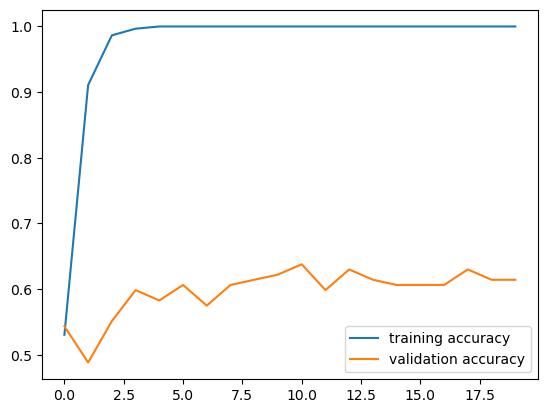

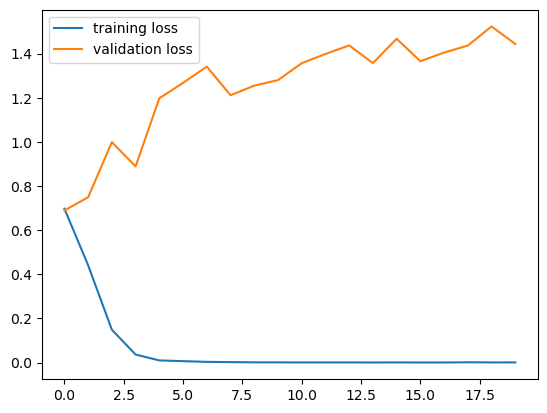

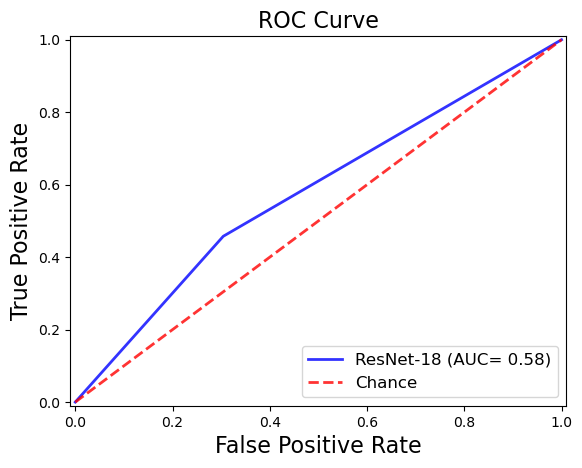

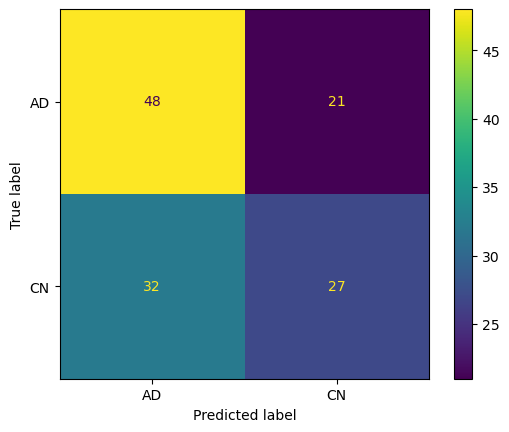

In [ ]:
### Training, validation, and testing plot
plt.plot(history_model_cnn.history["accuracy"], label="training accuracy")
plt.plot(history_model_cnn.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_cnn.history["loss"], label="training loss")
plt.plot(history_model_cnn.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ResNet-18 (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_cnn)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

### ViT

**Results**

In [ ]:
y_pred_vit = model_vit.predict(X_test_model, batch_size=batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_vit = np.argmax(y_pred_vit, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_vit)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_vit).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Standard ViT):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 1s 292ms/step
Results for Across Y - (Standard ViT):
tp: 35
tn: 32
fp: 27
fn: 34
Accuracy:  0.5234375
Sensitivity:  0.5072463768115942
Specificity:  0.5423728813559322
Precision:  0.5645161290322581
F1 Score: 0.534351145038168
AUC: 0.5248096290837632


**Plots**

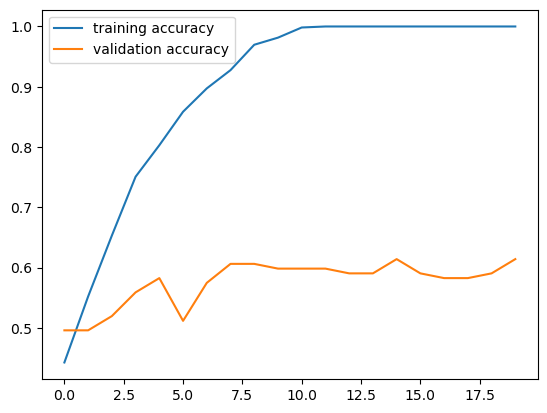

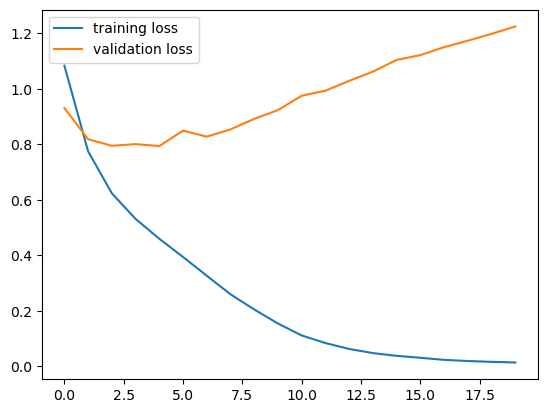

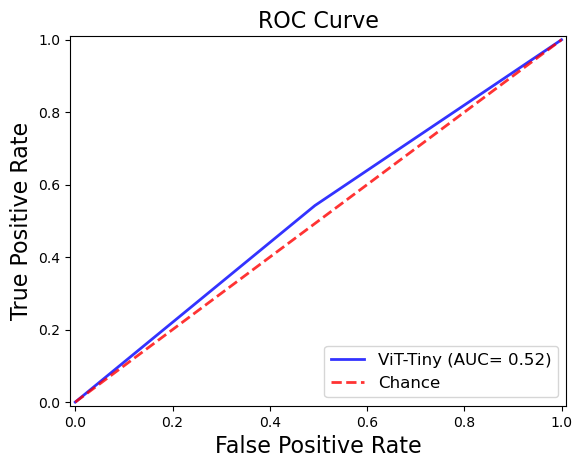

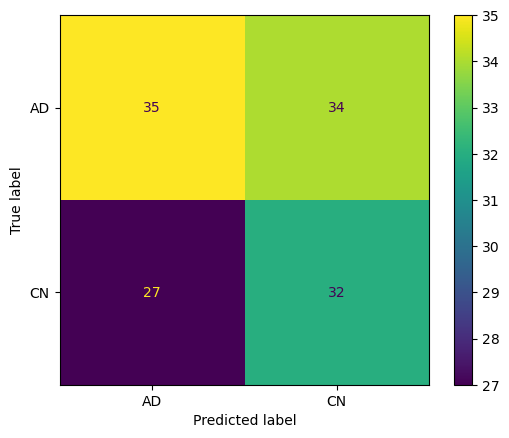

In [ ]:
### Training, validation, and testing plot
plt.plot(history_model_vit.history["accuracy"], label="training accuracy")
plt.plot(history_model_vit.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_vit.history["loss"], label="training loss")
plt.plot(history_model_vit.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ViT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_vit)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

### Pyramid ViT

**Results**

In [ ]:
y_pred_pvt = model_pvt.predict(X_test_model, batch_size=batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_pvt = np.argmax(y_pred_pvt, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_pvt)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_pvt).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Pyramid ViT-Tiny):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 4s 756ms/step
Results for Across Y - (Pyramid ViT-Tiny):
tp: 40
tn: 36
fp: 23
fn: 29
Accuracy:  0.59375
Sensitivity:  0.5797101449275363
Specificity:  0.6101694915254238
Precision:  0.6349206349206349
F1 Score: 0.6060606060606061
AUC: 0.59493981822648


**Plots**

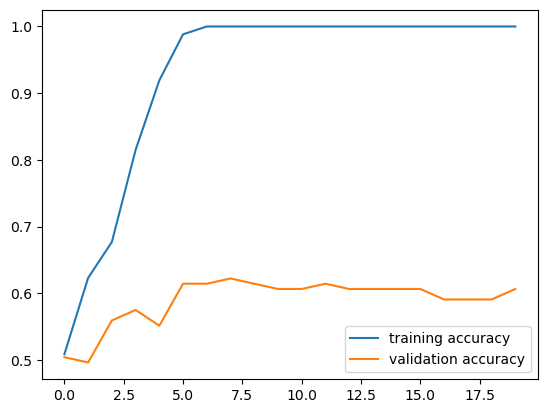

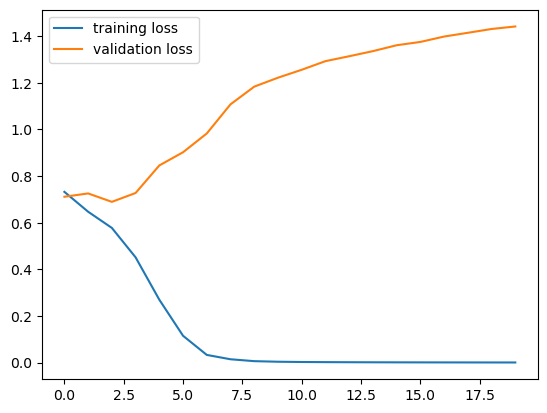

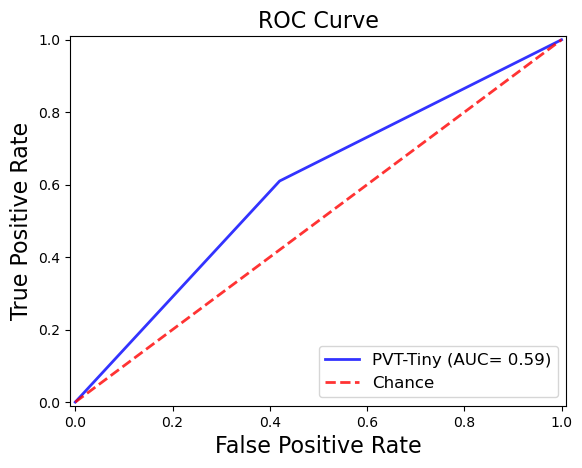

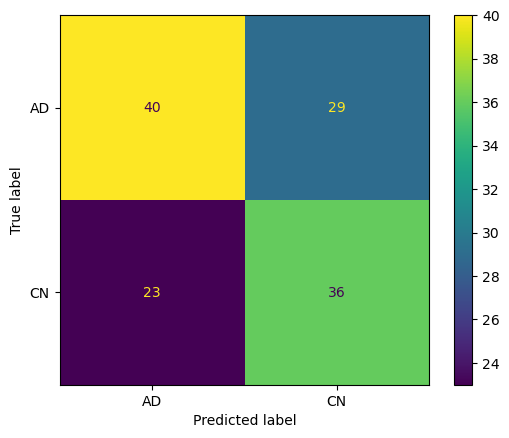

In [ ]:
### Training, validation, and testing plot
plt.plot(history_model_pvt.history["accuracy"], label="training accuracy")
plt.plot(history_model_pvt.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_pvt.history["loss"], label="training loss")
plt.plot(history_model_pvt.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'PVT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_pvt)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()